In [1]:
# Cell 1 - Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
DATA_RAW = Path('../data/raw')

# Column names - same as dissertation
index_names  = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = ['s_{}'.format(i+1) for i in range(21)]
col_names     = index_names + setting_names + sensor_names

# Load FD001
df_train = pd.read_csv(
    DATA_RAW / 'train_FD001.txt',
    sep='\s+', header=None, names=col_names
)
df_test = pd.read_csv(
    DATA_RAW / 'test_FD001.txt',
    sep='\s+', header=None, names=col_names
)
df_rul = pd.read_csv(
    DATA_RAW / 'RUL_FD001.txt',
    sep='\s+', header=None, names=['RUL']
)

print("=" * 50)
print("CMAPSS FD001 DATASET")
print("=" * 50)
print(f"Training set:  {df_train.shape[0]:,} rows x {df_train.shape[1]} columns")
print(f"Test set:      {df_test.shape[0]:,} rows x {df_test.shape[1]} columns")
print(f"RUL labels:    {df_rul.shape[0]} engines")
print(f"\nTraining engines: {df_train['unit_number'].nunique()}")
print(f"Test engines:     {df_test['unit_number'].nunique()}")
print(f"\nColumn names:\n{col_names}")

CMAPSS FD001 DATASET
Training set:  20,631 rows x 26 columns
Test set:      13,096 rows x 26 columns
RUL labels:    100 engines

Training engines: 100
Test engines:     100

Column names:
['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


In [2]:
# Cell 2 - first look at the data
print("first 5 rows of training data:")
print(df_train.head())

print("\nbasic stats:")
print(df_train.describe().round(2))

print("\nany missing values?")
print(df_train.isnull().sum().sum(), "missing values found")

print("\nhow many cycles does each engine run before failure?")
engine_life = df_train.groupby('unit_number')['time_cycles'].max()
print(f"  shortest engine life: {engine_life.min()} cycles")
print(f"  longest engine life:  {engine_life.max()} cycles")
print(f"  average engine life:  {engine_life.mean():.1f} cycles")

first 5 rows of training data:
   unit_number  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
0            1            1    -0.0007    -0.0004      100.0  518.67  641.82   
1            1            2     0.0019    -0.0003      100.0  518.67  642.15   
2            1            3    -0.0043     0.0003      100.0  518.67  642.35   
3            1            4     0.0007     0.0000      100.0  518.67  642.35   
4            1            5    -0.0019    -0.0002      100.0  518.67  642.37   

       s_3      s_4    s_5  ...    s_12     s_13     s_14    s_15  s_16  s_17  \
0  1589.70  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03   392   
1  1591.82  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03   392   
2  1587.99  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03   390   
3  1582.79  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03   392   
4  1582.85  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03   393   

 

constant sensors (dropping these):
  s_1: std = 0.000000
  s_5: std = 0.000000
  s_10: std = 0.000000
  s_16: std = 0.000000
  s_18: std = 0.000000
  s_19: std = 0.000000

useful sensors (15 remaining):
['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


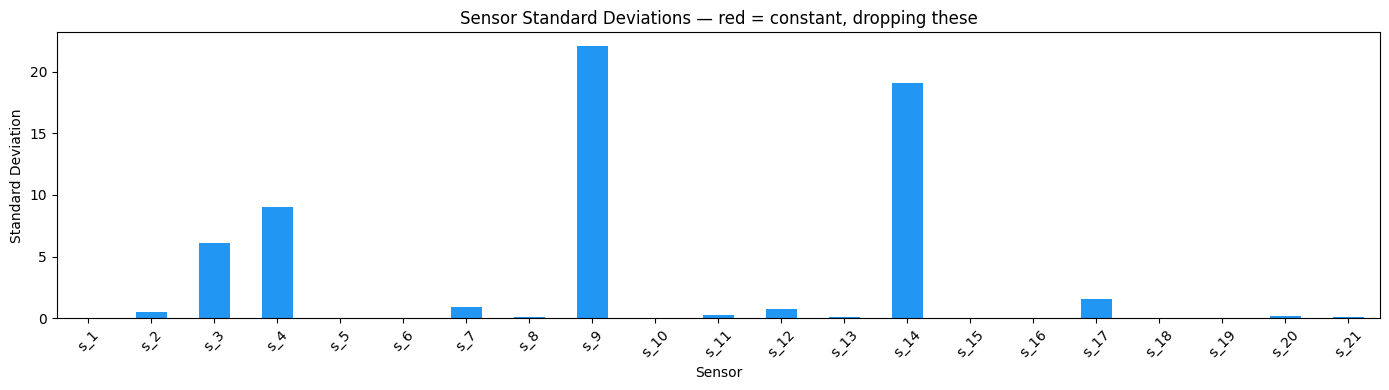

In [3]:
# Cell 3 - finding constant sensors to drop

sensor_cols = [f's_{i}' for i in range(1, 22)]

std_devs = df_train[sensor_cols].std()
constant_sensors = std_devs[std_devs < 0.001].index.tolist()
useful_sensors   = std_devs[std_devs >= 0.001].index.tolist()

print("constant sensors (dropping these):")
for s in constant_sensors:
    print(f"  {s}: std = {std_devs[s]:.6f}")

print(f"\nuseful sensors ({len(useful_sensors)} remaining):")
print(useful_sensors)

# visualise sensor variance to see which ones actually change
plt.figure(figsize=(14, 4))
std_devs.plot(kind='bar', color=[
    '#F44336' if s in constant_sensors else '#2196F3' 
    for s in sensor_cols
])
plt.title('Sensor Standard Deviations — red = constant, dropping these')
plt.xlabel('Sensor')
plt.ylabel('Standard Deviation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/sensor_variance.png', dpi=150)
plt.show()

RUL added to training data

RUL range: 0 to 361 cycles
average RUL across all rows: 107.8 cycles


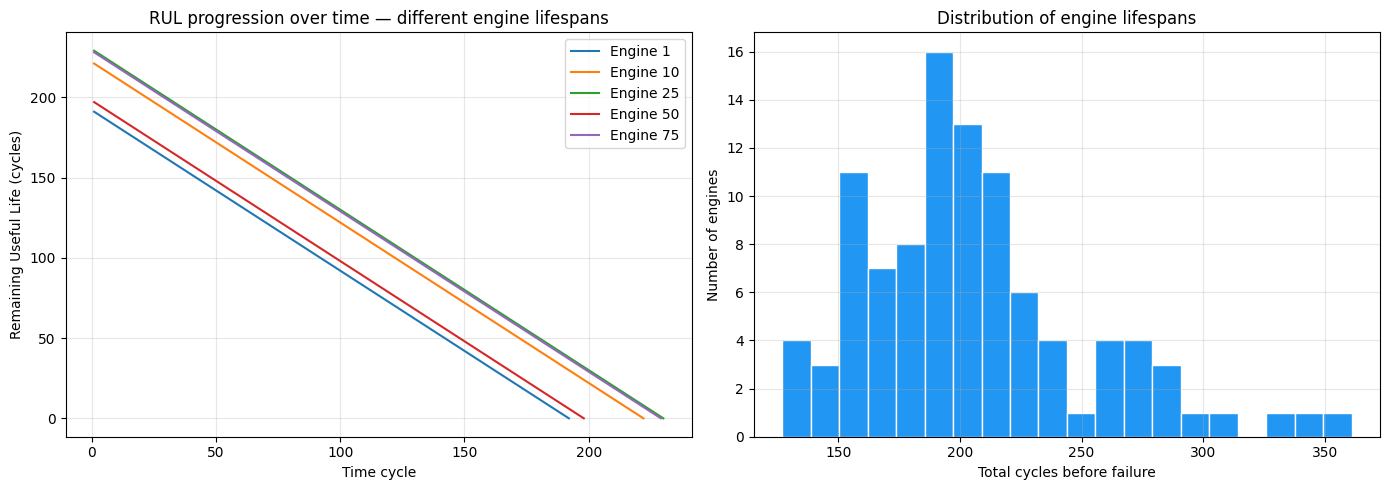

In [4]:
# Cell 4 - understanding RUL and how degradation progresses
# in CMAPSS, we know when each engine failed (end of training data)
# so we can calculate RUL for every cycle by counting backwards

# adding RUL column to training data
# for each engine: RUL at cycle t = max_cycles - t
df_train['RUL'] = df_train.groupby('unit_number')['time_cycles'].transform('max') - df_train['time_cycles']

print("RUL added to training data")
print(f"\nRUL range: {df_train['RUL'].min()} to {df_train['RUL'].max()} cycles")
print(f"average RUL across all rows: {df_train['RUL'].mean():.1f} cycles")

# show RUL progression for a few engines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: RUL over time for 5 sample engines
sample_engines = [1, 10, 25, 50, 75]
for eng in sample_engines:
    engine_data = df_train[df_train['unit_number'] == eng]
    axes[0].plot(engine_data['time_cycles'], engine_data['RUL'], 
                label=f'Engine {eng}')
axes[0].set_title('RUL progression over time — different engine lifespans')
axes[0].set_xlabel('Time cycle')
axes[0].set_ylabel('Remaining Useful Life (cycles)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right: distribution of max RUL (engine lifespans)
engine_lifespans = df_train.groupby('unit_number')['RUL'].max()
axes[1].hist(engine_lifespans, bins=20, color='#2196F3', edgecolor='white')
axes[1].set_title('Distribution of engine lifespans')
axes[1].set_xlabel('Total cycles before failure')
axes[1].set_ylabel('Number of engines')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/rul_progression.png', dpi=150)
plt.show()

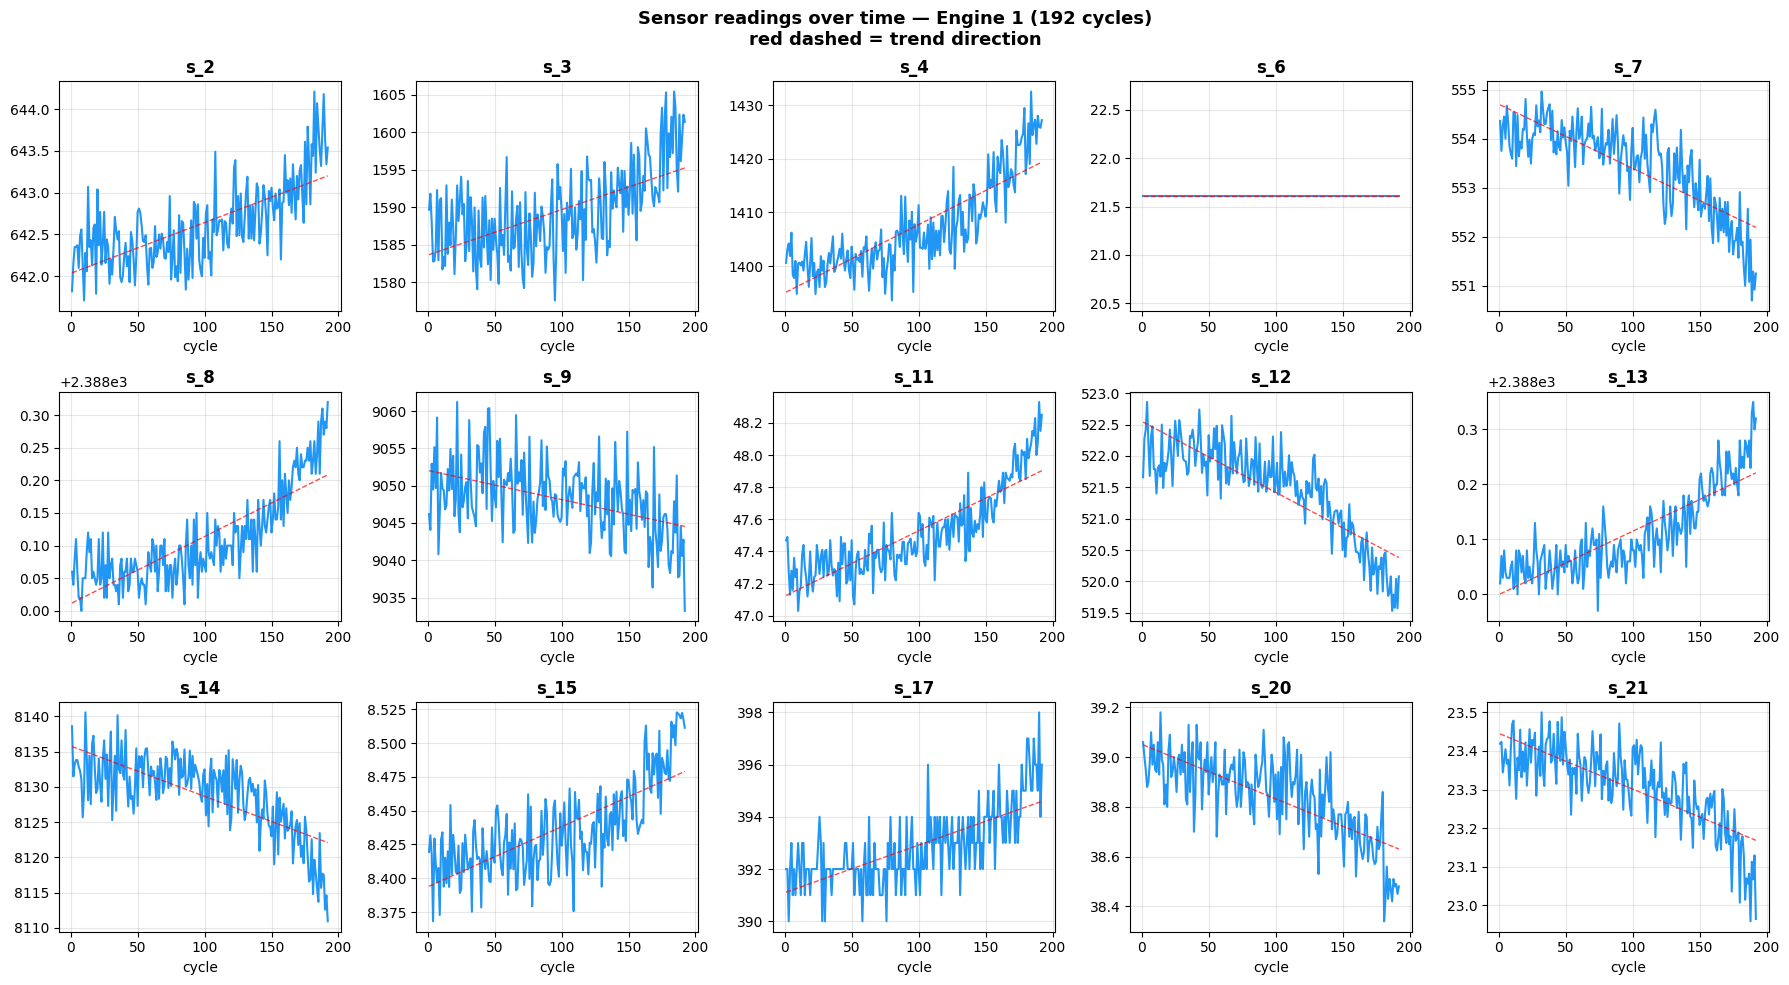

sensor trend directions (slope > 0 means increasing over time):
--------------------------------------------------
  s_2   : ↑ increasing  (slope: 0.0061)
  s_3   : ↑ increasing  (slope: 0.0605)
  s_4   : ↑ increasing  (slope: 0.1270)
  s_6   : ↑ increasing  (slope: 0.0000)
  s_7   : ↓ decreasing  (slope: -0.0131)
  s_8   : ↑ increasing  (slope: 0.0010)
  s_9   : ↓ decreasing  (slope: -0.0391)
  s_11  : ↑ increasing  (slope: 0.0041)
  s_12  : ↓ decreasing  (slope: -0.0113)
  s_13  : ↑ increasing  (slope: 0.0012)
  s_14  : ↓ decreasing  (slope: -0.0714)
  s_15  : ↑ increasing  (slope: 0.0004)
  s_17  : ↑ increasing  (slope: 0.0182)
  s_20  : ↓ decreasing  (slope: -0.0022)
  s_21  : ↓ decreasing  (slope: -0.0014)


In [5]:
# Cell 5 - sensor behaviour as engines degrade
# want to see which sensors show clear degradation trends

# picking engine 1 as example — runs for 192 cycles
engine1 = df_train[df_train['unit_number'] == 1].copy()

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, sensor in enumerate(useful_sensors):
    axes[i].plot(engine1['time_cycles'], engine1[sensor], 
                color='#2196F3', linewidth=1.5)
    axes[i].set_title(sensor, fontweight='bold')
    axes[i].set_xlabel('cycle')
    axes[i].grid(True, alpha=0.3)
    
    # add trend line to see degradation direction
    z = np.polyfit(engine1['time_cycles'], engine1[sensor], 1)
    p = np.poly1d(z)
    axes[i].plot(engine1['time_cycles'], p(engine1['time_cycles']), 
                'r--', linewidth=1, alpha=0.7, label=f'trend')

plt.suptitle('Sensor readings over time — Engine 1 (192 cycles)\nred dashed = trend direction', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/sensor_trends.png', dpi=150)
plt.show()

# which sensors increase vs decrease as engine degrades?
print("sensor trend directions (slope > 0 means increasing over time):")
print("-" * 50)
for sensor in useful_sensors:
    slope = np.polyfit(engine1['time_cycles'], engine1[sensor], 1)[0]
    direction = "↑ increasing" if slope > 0 else "↓ decreasing"
    print(f"  {sensor:<6}: {direction}  (slope: {slope:.4f})")

s_6 unique values: 2
s_6 std: 0.0013889849127073114

correlation with RUL (absolute values):
----------------------------------------
  s_11   ↓ 0.696  ████████████████████
  s_4    ↓ 0.679  ████████████████████
  s_12   ↑ 0.672  ████████████████████
  s_7    ↑ 0.657  ███████████████████
  s_15   ↓ 0.643  ███████████████████
  s_21   ↑ 0.636  ███████████████████
  s_20   ↑ 0.629  ██████████████████
  s_2    ↓ 0.606  ██████████████████
  s_17   ↓ 0.606  ██████████████████
  s_3    ↓ 0.585  █████████████████
  s_8    ↓ 0.564  ████████████████
  s_13   ↓ 0.563  ████████████████
  s_9    ↓ 0.390  ███████████
  s_14   ↓ 0.307  █████████
  s_6    ↓ 0.128  ███


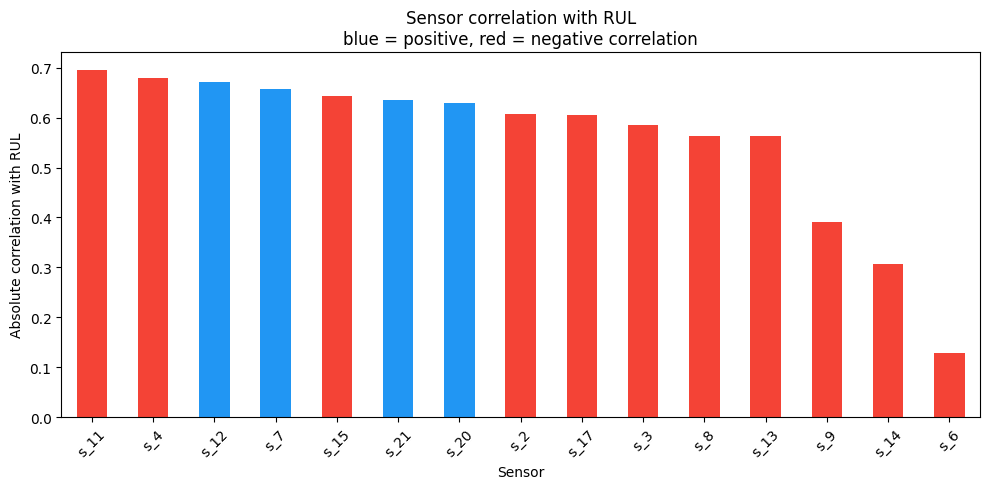


s_6 has very few unique values — dropping it too


In [6]:
# Cell 6 - checking s_6 more carefully and correlation with RUL
# s_6 looked flat in the sensor trends chart — worth investigating

print("s_6 unique values:", df_train['s_6'].nunique())
print("s_6 std:", df_train['s_6'].std())

# correlation of each sensor with RUL
# higher absolute correlation = more useful for prediction
correlations = df_train[useful_sensors + ['RUL']].corr()['RUL'].drop('RUL')
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("\ncorrelation with RUL (absolute values):")
print("-" * 40)
for sensor, corr in correlations_sorted.items():
    bar = "█" * int(abs(corr) * 30)
    direction = "↑" if correlations[sensor] > 0 else "↓"
    print(f"  {sensor:<6} {direction} {corr:.3f}  {bar}")

# visualise
plt.figure(figsize=(10, 5))
colors = ['#F44336' if correlations[s] < 0 else '#2196F3' 
          for s in correlations_sorted.index]
correlations_sorted.plot(kind='bar', color=colors)
plt.title('Sensor correlation with RUL\nblue = positive, red = negative correlation')
plt.xlabel('Sensor')
plt.ylabel('Absolute correlation with RUL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/sensor_correlation.png', dpi=150)
plt.show()

# decision on s_6
if df_train['s_6'].nunique() <= 2:
    print("\ns_6 has very few unique values — dropping it too")
else:
    print(f"\ns_6 has {df_train['s_6'].nunique()} unique values — keeping it")

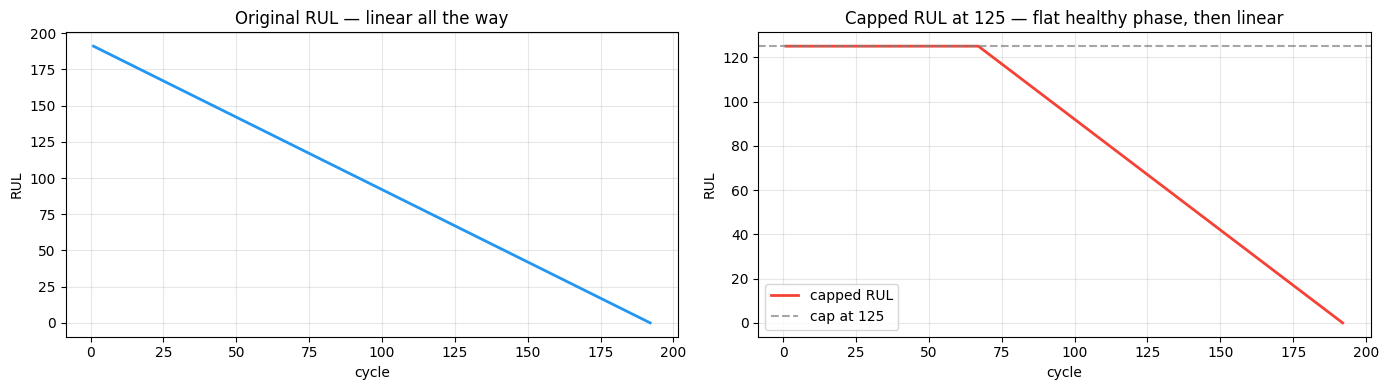

FINAL FEATURE DECISIONS

dropping 7 sensors: ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19', 's_6']

keeping 14 sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

RUL cap: 125 cycles

ready for preprocessing!


In [7]:
# Cell 7 - piecewise RUL and final feature decisions

RUL_CAP = 125

df_train['RUL_capped'] = df_train['RUL'].clip(upper=RUL_CAP)

# visualise the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

engine_sample = df_train[df_train['unit_number'] == 1]

axes[0].plot(engine_sample['time_cycles'], engine_sample['RUL'],
             color='#2196F3', linewidth=2, label='original RUL')
axes[0].set_title('Original RUL — linear all the way')
axes[0].set_xlabel('cycle')
axes[0].set_ylabel('RUL')
axes[0].grid(True, alpha=0.3)

axes[1].plot(engine_sample['time_cycles'], engine_sample['RUL_capped'],
             color='#F44336', linewidth=2, label='capped RUL')
axes[1].axhline(y=RUL_CAP, color='gray', linestyle='--', 
                alpha=0.7, label=f'cap at {RUL_CAP}')
axes[1].set_title(f'Capped RUL at {RUL_CAP} — flat healthy phase, then linear')
axes[1].set_xlabel('cycle')
axes[1].set_ylabel('RUL')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/rul_capping.png', dpi=150)
plt.show()

# final feature decisions
FEATURES_TO_DROP  = constant_sensors + ['s_6']
FINAL_FEATURES    = [s for s in useful_sensors if s != 's_6']

print("=" * 50)
print("FINAL FEATURE DECISIONS")
print("=" * 50)
print(f"\ndropping {len(FEATURES_TO_DROP)} sensors: {FEATURES_TO_DROP}")
print(f"\nkeeping {len(FINAL_FEATURES)} sensors: {FINAL_FEATURES}")
print(f"\nRUL cap: {RUL_CAP} cycles")
print(f"\nready for preprocessing!")